In [ ]:
!unzip circut board.zip -d /content/circuit board

unzip:  cannot find or open circut, circut.zip or circut.ZIP.


In [ ]:
!unzip "/content/circut board.zip" -d /content/circut_board


Archive:  /content/circut board.zip
 extracting: /content/circut_board/README.dataset.txt  
 extracting: /content/circut_board/README.roboflow.txt  
 extracting: /content/circut_board/data.yaml  
   creating: /content/circut_board/test/
   creating: /content/circut_board/test/images/
 extracting: /content/circut_board/test/images/ATTIOT_Bottom_jpg.rf.94cd89169043c7506cde7ced6de19680.jpg  
 extracting: /content/circut_board/test/images/ATTIOT_Bottom_jpg.rf.a4f31e8c2d624c9e47b1e2f24ee88e69.jpg  
 extracting: /content/circut_board/test/images/Arty_Bottom_jpg.rf.16f36245a0765afee4ea9dd43ae09f68.jpg  
 extracting: /content/circut_board/test/images/Arty_Bottom_jpg.rf.b990509a5c76764e81f3e4e3a83b2711.jpg  
 extracting: /content/circut_board/test/images/Arty_Top_jpg.rf.5d15b4645b32647b6439efa7fe4e3942.jpg  
 extracting: /content/circut_board/test/images/Arty_Top_jpg.rf.7bc260a89099530b771500c983e1669e.jpg  
 extracting: /content/circut_board/test/images/DuetWIFI_Top_png_jpg.rf.0b9a1e43b5f2dcef

In [ ]:
import os
import yaml
import shutil
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
from google.colab import drive
from ultralytics import YOLO
import cv2
import numpy as np

# Check if GPU is available
import torch


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
PyTorch version: 2.9.0+cpu
CUDA available: False


In [ ]:
DATASET_PATH = '/content/circut_board'  # Change this to your actual path

print(f"Dataset path: {DATASET_PATH}")
print(f"Dataset exists: {os.path.exists(DATASET_PATH)}")

Dataset path: /content/circut_board
Dataset exists: True


In [ ]:
def analyze_dataset_structure(dataset_path):
    """
    Analyze and display dataset structure and statistics
    """
    splits = ['train', 'valid', 'test']

    print("="*60)
    print("DATASET STRUCTURE ANALYSIS")
    print("="*60)

    for split in splits:
        split_path = os.path.join(dataset_path, split)
        images_path = os.path.join(split_path, 'images')
        labels_path = os.path.join(split_path, 'labels')

        if os.path.exists(images_path) and os.path.exists(labels_path):
            num_images = len([f for f in os.listdir(images_path) if f.endswith(('.jpg', '.jpeg', '.png'))])
            num_labels = len([f for f in os.listdir(labels_path) if f.endswith('.txt')])

            print(f"\n{split.upper()} Split:")
            print(f"  Images: {num_images}")
            print(f"  Labels: {num_labels}")
            print(f"  Match: {'✓' if num_images == num_labels else '✗ WARNING: Mismatch!'}")
        else:
            print(f"\n{split.upper()} Split: NOT FOUND")

    print("\n" + "="*60)

# Run the analysis
analyze_dataset_structure(DATASET_PATH)

DATASET STRUCTURE ANALYSIS

TRAIN Split:
  Images: 548
  Labels: 548
  Match: ✓

VALID Split:
  Images: 80
  Labels: 80
  Match: ✓

TEST Split:
  Images: 44
  Labels: 44
  Match: ✓



In [ ]:
def extract_class_info(dataset_path):
    """
    Extract class IDs from label files and count instances
    """
    class_counts = {}

    for split in ['train', 'valid', 'test']:
        labels_path = os.path.join(dataset_path, split, 'labels')

        if os.path.exists(labels_path):
            for label_file in os.listdir(labels_path):
                if label_file.endswith('.txt'):
                    with open(os.path.join(labels_path, label_file), 'r') as f:
                        for line in f:
                            if line.strip():
                                class_id = int(line.split()[0])
                                class_counts[class_id] = class_counts.get(class_id, 0) + 1

    print("\nCLASS DISTRIBUTION:")
    print("="*40)
    for class_id in sorted(class_counts.keys()):
        print(f"Class {class_id}: {class_counts[class_id]} instances")
    print("="*40)

    return sorted(class_counts.keys())

# Extract class information
class_ids = extract_class_info(DATASET_PATH)
num_classes = len(class_ids)
print(f"\nTotal number of classes: {num_classes}")


CLASS DISTRIBUTION:
Class 0: 277 instances
Class 1: 19034 instances
Class 2: 32564 instances
Class 3: 146 instances
Class 4: 4558 instances
Class 5: 284 instances
Class 6: 162 instances
Class 7: 856 instances
Class 8: 108 instances
Class 9: 7481 instances
Class 10: 235 instances
Class 11: 324 instances
Class 12: 784 instances
Class 13: 1176 instances
Class 14: 1212 instances
Class 15: 16034 instances
Class 16: 37329 instances
Class 17: 4627 instances
Class 18: 189 instances
Class 19: 1289 instances
Class 20: 4273 instances
Class 21: 982 instances
Class 22: 123 instances

Total number of classes: 23


In [ ]:
CLASS_NAMES = [
    'resistor',
    'capacitor',
    'diode',
    'transistor',
    'IC',
    'LED',
    'switch',
    'connector'
    # Add more component names as needed
]

# Ensure we have enough class names
while len(CLASS_NAMES) < num_classes:
    CLASS_NAMES.append(f'component_{len(CLASS_NAMES)}')

# Create YAML configuration
yaml_content = {
    'path': DATASET_PATH,
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
    'nc': num_classes,
    'names': CLASS_NAMES[:num_classes]
}

# Save YAML file
yaml_path = '/content/circuit_dataset.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(yaml_content, f, default_flow_style=False)

print("Dataset configuration saved to:", yaml_path)
print("\nConfiguration:")
print(yaml.dump(yaml_content, default_flow_style=False))

Dataset configuration saved to: /content/circuit_dataset.yaml

Configuration:
names:
- resistor
- capacitor
- diode
- transistor
- IC
- LED
- switch
- connector
- component_8
- component_9
- component_10
- component_11
- component_12
- component_13
- component_14
- component_15
- component_16
- component_17
- component_18
- component_19
- component_20
- component_21
- component_22
nc: 23
path: /content/circut_board
test: test/images
train: train/images
val: valid/images



Visualizing training samples with annotations...



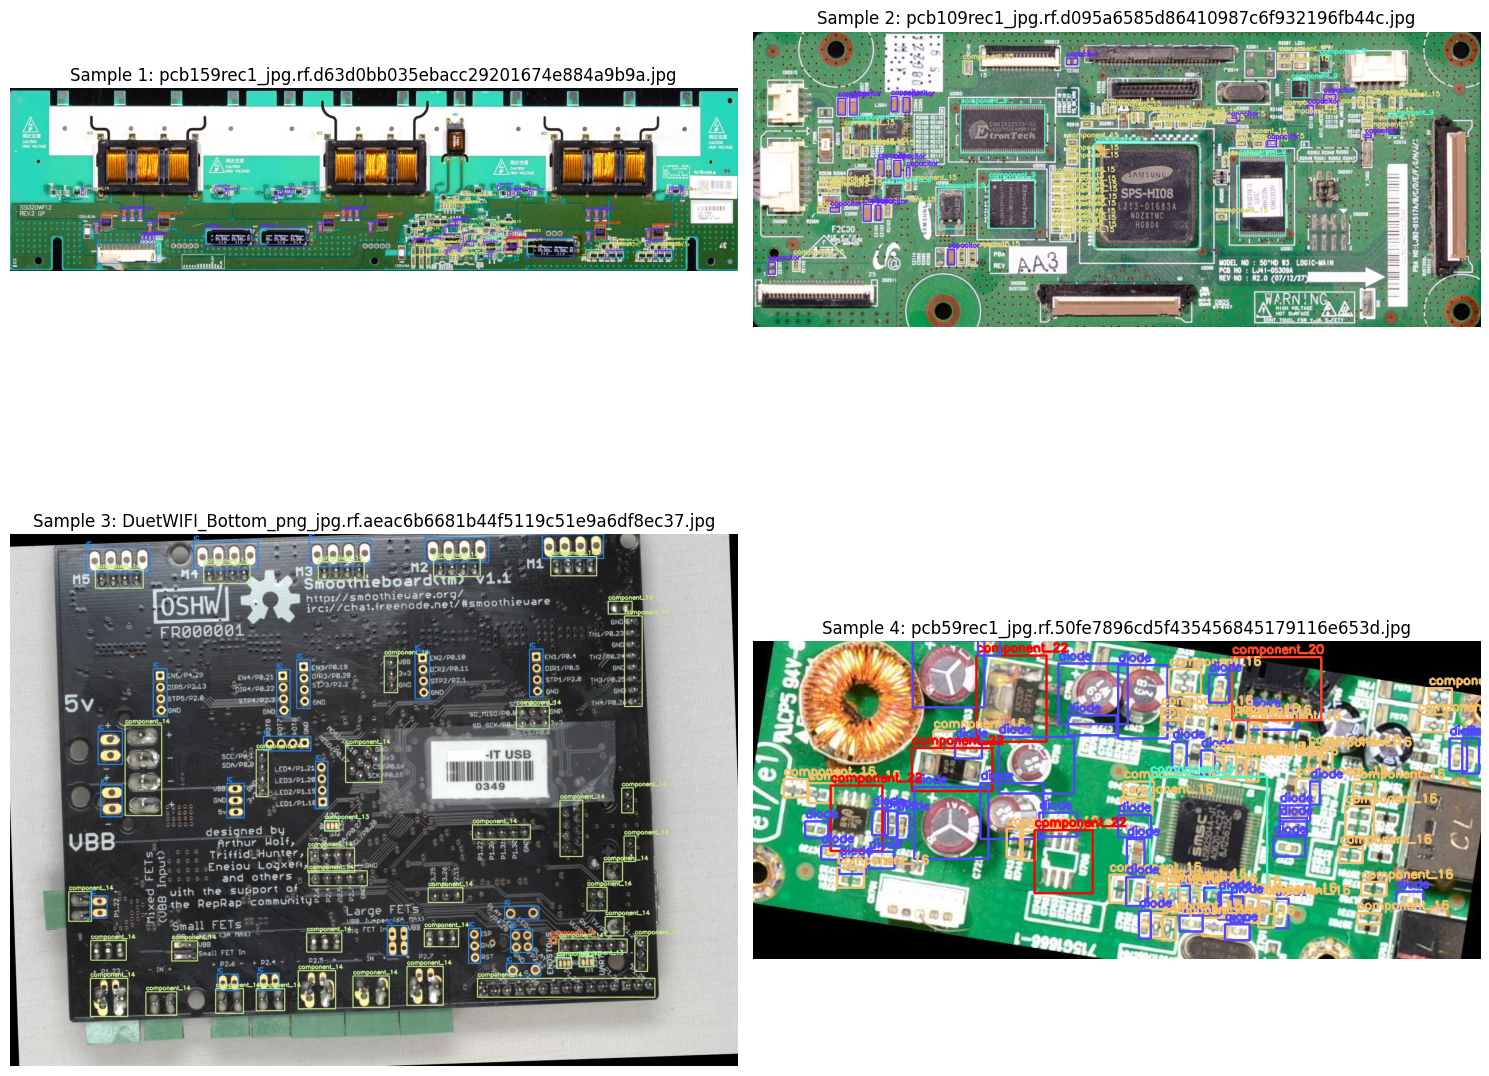

In [ ]:
def visualize_samples(dataset_path, split='train', num_samples=4):
    """
    Visualize sample images with bounding boxes
    """
    images_path = os.path.join(dataset_path, split, 'images')
    labels_path = os.path.join(dataset_path, split, 'labels')

    image_files = [f for f in os.listdir(images_path) if f.endswith(('.jpg', '.jpeg', '.png'))][:num_samples]

    fig, axes = plt.subplots(2, 2, figsize=(15, 15))
    axes = axes.ravel()

    colors = plt.cm.rainbow(np.linspace(0, 1, num_classes))

    for idx, img_file in enumerate(image_files):
        # Read image
        img_path = os.path.join(images_path, img_file)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        # Read labels
        label_file = os.path.splitext(img_file)[0] + '.txt'
        label_path = os.path.join(labels_path, label_file)

        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                for line in f:
                    if line.strip():
                        class_id, x_center, y_center, width, height = map(float, line.split())
                        class_id = int(class_id)

                        # Convert YOLO format to pixel coordinates
                        x1 = int((x_center - width/2) * w)
                        y1 = int((y_center - height/2) * h)
                        x2 = int((x_center + width/2) * w)
                        y2 = int((y_center + height/2) * h)

                        # Draw bounding box
                        color = tuple(int(c * 255) for c in colors[class_id][:3])
                        cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)

                        # Add label
                        label = CLASS_NAMES[class_id] if class_id < len(CLASS_NAMES) else f'Class {class_id}'
                        cv2.putText(img, label, (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)

        axes[idx].imshow(img)
        axes[idx].set_title(f'Sample {idx+1}: {img_file}')
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()

# Visualize training samples
print("Visualizing training samples with annotations...\n")
visualize_samples(DATASET_PATH, 'train', 4)

In [ ]:
# Training Configuration
MODEL_SIZE = 'yolov8n.pt'  # Change to 's', 'm', 'l', or 'x' for larger models
EPOCHS = 100               # Number of training epochs
IMG_SIZE = 640             # Input image size
BATCH_SIZE = 16            # Batch size (-1 for auto)
PATIENCE = 50              # Early stopping patience
# Initialize YOLO model
model = YOLO(MODEL_SIZE)

# Auto-detect device (GPU if available, else CPU)
import torch
device = 0 if torch.cuda.is_available() else 'cpu'

print(f"Starting training with {MODEL_SIZE}...\n")
print(f"Configuration:")
print(f"  Device: {device} ({'GPU' if device == 0 else 'CPU'})")
print(f"  Epochs: {EPOCHS}")
print(f"  Image Size: {IMG_SIZE}")
print(f"  Batch Size: {BATCH_SIZE}")
print(f"  Patience: {PATIENCE}")
print(f"\nTraining will be saved to: /content/runs/detect/train\n")

# Adjust batch size for CPU if needed
if device == 'cpu' and BATCH_SIZE > 8:
    BATCH_SIZE = 4  # Reduce batch size for CPU
    print(f"⚠️ Running on CPU - reducing batch size to {BATCH_SIZE}\n")

# Train the model
results = model.train(
    data=yaml_path,
    epochs=EPOCHS,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    patience=PATIENCE,
    device=device,  # Auto-detected device
    project='/content/runs/detect',
    name='train',
    exist_ok=True,
    pretrained=True,
    optimizer='auto',
    verbose=True,
    seed=42,
    deterministic=False,
    single_cls=False,
    rect=False,
    cos_lr=False,
    close_mosaic=10,
    resume=False,
    amp=True,  # Automatic Mixed Precision
    fraction=1.0,
    profile=False,
    lr0=0.01,
    lrf=0.01,
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=3.0,
    warmup_momentum=0.8,
    warmup_bias_lr=0.1,
    box=7.5,
    cls=0.5,
    dfl=1.5,
    pose=12.0,
    kobj=1.0,
    nbs=64,
    hsv_h=0.015,
    hsv_s=0.7,
    hsv_v=0.4,
    degrees=0.0,
    translate=0.1,
    scale=0.5,
    shear=0.0,
    perspective=0.0,
    flipud=0.0,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.0,
    copy_paste=0.0
)

print("\n" + "="*60)
print("TRAINING COMPLETED!")
print("="*60)

In [ ]:
from IPython.display import Image as IPImage, display

results_path = '/content/runs/detect/train'

print("TRAINING RESULTS VISUALIZATION")
print("="*60)

# Display results curve
results_plot = os.path.join(results_path, 'results.png')
if os.path.exists(results_plot):
    print("\n1. Training Metrics Over Epochs:")
    display(IPImage(filename=results_plot, width=900))

# Display confusion matrix
confusion_matrix = os.path.join(results_path, 'confusion_matrix.png')
if os.path.exists(confusion_matrix):
    print("\n2. Confusion Matrix:")
    display(IPImage(filename=confusion_matrix, width=700))

# Display F1 curve
f1_curve = os.path.join(results_path, 'F1_curve.png')
if os.path.exists(f1_curve):
    print("\n3. F1-Confidence Curve:")
    display(IPImage(filename=f1_curve, width=700))

# Display PR curve
pr_curve = os.path.join(results_path, 'PR_curve.png')
if os.path.exists(pr_curve):
    print("\n4. Precision-Recall Curve:")
    display(IPImage(filename=pr_curve, width=700))

# Display prediction examples
val_batch_labels = os.path.join(results_path, 'val_batch0_labels.jpg')
if os.path.exists(val_batch_labels):
    print("\n5. Validation Batch - Ground Truth Labels:")
    display(IPImage(filename=val_batch_labels, width=900))

val_batch_pred = os.path.join(results_path, 'val_batch0_pred.jpg')
if os.path.exists(val_batch_pred):
    print("\n6. Validation Batch - Predictions:")
    display(IPImage(filename=val_batch_pred, width=900))

TRAINING RESULTS VISUALIZATION


In [ ]:
# Load the best trained model
# Fix: Don't use os.path.join with absolute path in second argument
best_model_path = '/content/runs/detect/train/weights/best.pt'
model = YOLO(best_model_path)

# Auto-detect device (GPU if available, else CPU)
import torch
device = 0 if torch.cuda.is_available() else 'cpu'

print(f"Using device: {device} ({'GPU' if device == 0 else 'CPU'})")
print("Evaluating model on test set...\n")

# Run validation on test set
test_results = model.val(
    data=yaml_path,
    split='test',
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    conf=0.001,
    iou=0.6,
    device=device,  # Changed from device=0 to auto-detected device
    project='/content/runs/detect',
    name='test',
    exist_ok=True
)

print("\n" + "="*60)
print("TEST SET RESULTS")
print("="*60)
print(f"mAP50: {test_results.box.map50:.4f}")
print(f"mAP50-95: {test_results.box.map:.4f}")
print(f"Precision: {test_results.box.mp:.4f}")
print(f"Recall: {test_results.box.mr:.4f}")
print("="*60)

# Display per-class metrics
print("\nPER-CLASS METRICS:")
print("-" * 60)
for i, class_name in enumerate(CLASS_NAMES[:num_classes]):
    if i < len(test_results.box.maps):
        print(f"{class_name:20s} - mAP50: {test_results.box.maps[i]:.4f}")

In [ ]:
test_images_path = os.path.join(DATASET_PATH, 'test', 'images')
test_images = [os.path.join(test_images_path, f) for f in os.listdir(test_images_path)
               if f.endswith(('.jpg', '.jpeg', '.png'))][:4]  # Take first 4 images

print("Running inference on test images...\n")

# Predict
predictions = model.predict(
    source=test_images,
    imgsz=IMG_SIZE,
    conf=0.25,
    iou=0.45,
    device='cpu',   # <- CHANGE HERE
    save=True,
    save_txt=False,
    save_conf=True,
    project='/content/runs/detect',
    name='inference',
    exist_ok=True
)

print(f"Inference completed! Results saved to: /content/runs/detect/inference\n")

# Display inference results
print("INFERENCE RESULTS:")
print("="*60)
for i, pred in enumerate(predictions):
    print(f"\nImage {i+1}: {os.path.basename(test_images[i])}")
    print(f"  Detected objects: {len(pred.boxes)}")

    if len(pred.boxes) > 0:
        for box in pred.boxes:
            class_id = int(box.cls[0])
            confidence = float(box.conf[0])
            class_name = CLASS_NAMES[class_id] if class_id < len(CLASS_NAMES) else f'Class {class_id}'
            print(f"    - {class_name}: {confidence:.2%}")

Running inference on test images...


0: 640x640 (no detections), 215.9ms
1: 640x640 (no detections), 215.9ms
2: 640x640 (no detections), 215.9ms
3: 640x640 (no detections), 215.9ms
Speed: 10.1ms preprocess, 215.9ms inference, 1.0ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/runs/detect/inference
Inference completed! Results saved to: /content/runs/detect/inference

INFERENCE RESULTS:

Image 1: pcb18rec1_jpg.rf.fa2e7342ecf9328b387e95121d11384d.jpg
  Detected objects: 0

Image 2: XCM-307A_Top_jpg.rf.56b3bda16f0abd39061675d240381c1a.jpg
  Detected objects: 0

Image 3: pcb125rec1_jpg.rf.0ca0057c3592554edfc2f19cd0157636.jpg
  Detected objects: 0

Image 4: pcb69rec1_jpg.rf.b85b517477c4c8e4b5cdfa842ce474b1.jpg
  Detected objects: 0


In [ ]:
# Display inference results
inference_path = '/content/runs/detect/inference'
inference_images = [os.path.join(inference_path, f) for f in os.listdir(inference_path)
                   if f.endswith(('.jpg', '.jpeg', '.png'))][:4]

if inference_images:
    fig, axes = plt.subplots(2, 2, figsize=(15, 15))
    axes = axes.ravel()

    for idx, img_path in enumerate(inference_images):
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        axes[idx].imshow(img)
        axes[idx].set_title(f'Detection Result {idx+1}')
        axes[idx].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No inference images found.")